In [132]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import pickle

from random import choices

In [5]:
medical_term_mapping = {
    'ABSCESS': r'.*ABSCESS.*',
    'ANKYLOSIS': r'.*ANKYLOSIS.*',
    'ANEMIA': r'.*ANEMIA.*',
    'APHONIA': r'.*APHONIA.*',
    'ASCITES': r'.*ASCITES.*',
    'BILIOUS': r'.*BILIOUS.*',
    'BOIL': r'.*BOIL.*',
    'BRONCHITIS': r'.*BRONCHITIS.*',
    'BRUISE': r'.*BRUISE.*',
    'BUNION': r'.*BUNION.*',
    'CATARRH': r'.*CATARRH.*',
    'CONJUNCTIVITIS': r'.*CONJUNCTIVITIS.*',
    'CONSTIPATION': r'.*CONSTIPATION.*',
    'CONVALESCENT': r'.*CONVAL.*',
    'COUGH': r'.*COUGH.*',
    'DEAFNESS/DEAF': r'.*DEAF.*',
    'DEBILITY': r'.*DEBILITY.*',
    'DIARRHEA': r'.*DIARRHEA.*',
    'DIPHTHERIA': r'.*DIPHTHERIA.*',
    'DYSENTERY': r'.*DYSENTERY.*',
    'EDEMA': r'.*EDEMA.*',
    'ENDOCARDITIS': r'.*ENDOCARDITIS.*',
    'EPILEPTIC': r'.*EPILEPT.*',
    'ERYSIPELAS': r'.*ERYSIPELAS.*',
    'EYES': r'.*EYES.*',
    'FEVER': r'.*FEVER.*',
    'GASTROINTESTIN': r'.*GASTRO.*',
    'GONORRHEA': r'.*GONORRHEA.*',
    'GSW': r'.*GSW.*',
    'HEART': r'.*HEART.*',
    'HEMORRHOIDS': r'.*HEMORRHOI.*',
    'HERNIA': r'.*HERNIA.*',
    'HYPERTROPHY': r'.*HYPERTRO.*',
    'ICTEROID': r'.*ICTEROID.*',
    'INFLAMMATION': r'.*INFLAM.*',
    'JAUNDICE': r'.*JAUNDICE.*',
    'LARYNGITIS': r'.*LARYNGITIS.*',
    'LUMBAGO': r'.*LUMBAGO.*',
    'LUNG': r'.*LUNG.*',
    'MALARIA': r'.*MALARIA.*',
    'MENINGITIS': r'.*MENINGITIS.*',
    'MUMPS': r'.*MUMPS.*',
    'NEPHRITIS': r'.*NEPHRITIS.*',
    'NERVES/NERVOUS': r'.*NERV.*',
    'PAROTITIS': r'.*PAROTITIS.*',
    'PLEURITIC/PLEURI': r'.*PLEURI.*',
    'PNEUMONIA': r'.*PNEUMONIA.*',
    'PURULENT': r'.*PURULENT.*',
    'RHEUMATISM': r'.*RHEUMATISM.*',
    'SCURVY': r'.*SCURVY.*',
    'SICK': r'.*SICK.*',
    'SMALLPOX': r'.*SMALLPOX.*',
    'SPRAIN': r'.*SPRAIN.*',
    'SYPHILIS': r'.*SYPHILIS.*',
    'THYROID': r'.*THYROID.*',
    'TYPHOID': r'.*TYPHOID.*',
    'TONSIL': r'.*TONSIL.*',
    'TUBERCULOSIS/TUBERCULAR': r'.*TUBERCUL.*',
    'ULCER': r'.*ULCER.*',
    'ULCERATION': r'.*ULCERATION.*',
    'VARIOLOID': r'.*VARIOLOID.*',
    'VULNUS SCLOPIT/VS': r'.*VULNUS.*',
    'WND/WOUND': r'.*WND.*',
    'MEASLES': r'.*MEASLES.*',
    'RUBEOLA': r'.*RUBEOLA.*'
}



In [47]:
#commented out conditions didn't appear in the group of 351 and/or didn't have an assigned condition group or stand alone status 
condition_groups = {
    'ABSCESS': 'skin/surface infection',
    'ANKYLOSIS': 'joint',
    'ANEMIA': 'cardiovascular',
    'APHONIA': 'pulmonary',
    #'ASCITES': r'.*ASCITES.*',
    'BILIOUS': 'gastrointestinal',
    'BOIL': 'skin/surface infection',
    'BRONCHITIS': 'pulmonary',
    'BRUISE': 'mechanical',
    'BUNION': 'mechanical',
    'CATARRH': 'pulmonary',
    'CONJUNCTIVITIS': 'ocular',
    'CONSTIPATION': 'gastrointestinal',
    'CONVALESCENT': 'malaise',
    'COUGH': 'pulmonary',
    'DEAFNESS/DEAF': 'otic',
    'DEBILITY': 'malaise',
    'DIARRHEA': 'gastrointestinal',
    'DIPHTHERIA': 'infectious',
    'DYSENTERY': 'gastrointestinal',
    'EDEMA': 'cardiovascular',
    'ENDOCARDITIS': 'cardiovascular',
    'EPILEPTIC': 'nervous',
    'ERYSIPELAS': 'skin/surface infection',
    'EYES': 'ocular',
    'FEVER': 'fever',
    'GASTROINTESTIN': 'gastrointestinal',
    'GONORRHEA': 'venereal',
    'GSW': 'wound',
    'HEART': 'cardiovascular',
    'HEMORRHOIDS': 'gastrointestinal',
    'HERNIA': 'mechanical',
    #'HYPERTROPHY': r'.*HYPERTRO.*',
    'ICTEROID': 'infectious',
    'INFLAMMATION': 'inflammation',
    'JAUNDICE': 'infectious',
    'LARYNGITIS': 'pulmonary',
    'LUMBAGO': 'mechanical',
    'LUNG': 'pulmonary',
    'MALARIA': 'malaria',
    'MENINGITIS': 'infectious',
    'MUMPS': 'infectious',
    'NEPHRITIS': 'nephritis',
    'NERVES/NERVOUS': 'nervous',
    'PAROTITIS': 'infectious',
    'PLEURITIC/PLEURI': 'pulmonary',
    'PNEUMONIA': 'pulmonary',
    'PURULENT': 'skin/surface infection',
    'RHEUMATISM': 'rheumatism',
    'SCURVY': 'scurvy',
    'SICK': 'sick',
    'SMALLPOX': 'smallpox',
    'SPRAIN': 'mechanical',
    'SYPHILIS': 'venereal',
    #'THYROID': r'.*THYROID.*',
    'TYPHOID': 'gastrointestinal',
    'TONSIL': 'pulmonary',
    'TUBERCULOSIS/TUBERCULAR': 'tuberculosis',
    'ULCER': 'skin/surface infection',
    'ULCERATION': 'skin/surface infection',
    'VARIOLOID': 'smallpox',
    'VULNUS SCLOPIT/VS': 'wound',
    'WND/WOUND': 'wound',
    'MEASLES': 'measles',
    'RUBEOLA': 'measles'
}

In [49]:
data = pd.read_csv('~/projects/measles_analysis/measles_set_clean.csv', index_col='recidnum', na_values='0')
data.shape

(351, 15)

In [50]:
print("Number of cells in the dataframe that identify a condition (are not empty):", pd.notna(data.values.ravel()).sum())
print("Number of conditions contained in data before standardizing terms:", len(pd.unique(data.values.ravel())))

Number of cells in the dataframe that identify a condition (are not empty): 960
Number of conditions contained in data before standardizing terms: 226


In [90]:
#take each row, search for the terms in the medical_term_mapping, add found items to a dict where {recid :[list of conditions]}
standardized = {}

for i, row in data.iterrows():
    conditions = []
    row = row.dropna().tolist()
    for text in row:
        for standard_term, pattern in medical_term_mapping.items():
            if re.search(pattern, text, re.IGNORECASE):
                conditions.append(standard_term)
    
    standardized[i] = conditions

In [91]:
standardized = pd.DataFrame.from_dict(standardized, orient='index')

In [92]:
print("Number of conditions contained in data after standardizing terms:", len(pd.unique(standardized.values.ravel())))

Number of conditions contained in data after standardizing terms: 46


In [75]:
grouped = {}

for i, v in standardized.items():
    conditionGroups = []
    
    for cond in v:
        conditionGroups.append(condition_groups[cond])

    grouped[i] = conditionGroups

In [95]:
grouped = standardized.replace(condition_groups)

In [96]:
print("Number of condition groups contained in data after standardizing terms:", len(pd.unique(grouped.values.ravel())))

Number of condition groups contained in data after standardizing terms: 22


In [128]:
standardized.to_csv('~/projects/measles_analysis/StandardizedData.csv')
grouped.to_csv('~/projects/measles_analysis/GroupedData.csv')

In [102]:
n_bootstraps = 10000
samples = []
counts = {}

for i in range(n_bootstraps):
    sample = grouped.sample(n=len(grouped), replace=True)
    samples.append(sample)

    counts[i] = (pd.Series(sample.values.ravel())).value_counts()

In [ ]:
resultsBySample = pd.DataFrame.from_dict(counts, orient='index')

In [140]:
with open('~/projects/measles_analysis/bootstraps.pkl', 'wb') as f:
    pickle.dump(samples, f)

resultsBySample.to_csv('~/projects/measles_analysis/ResultsBySample.csv')

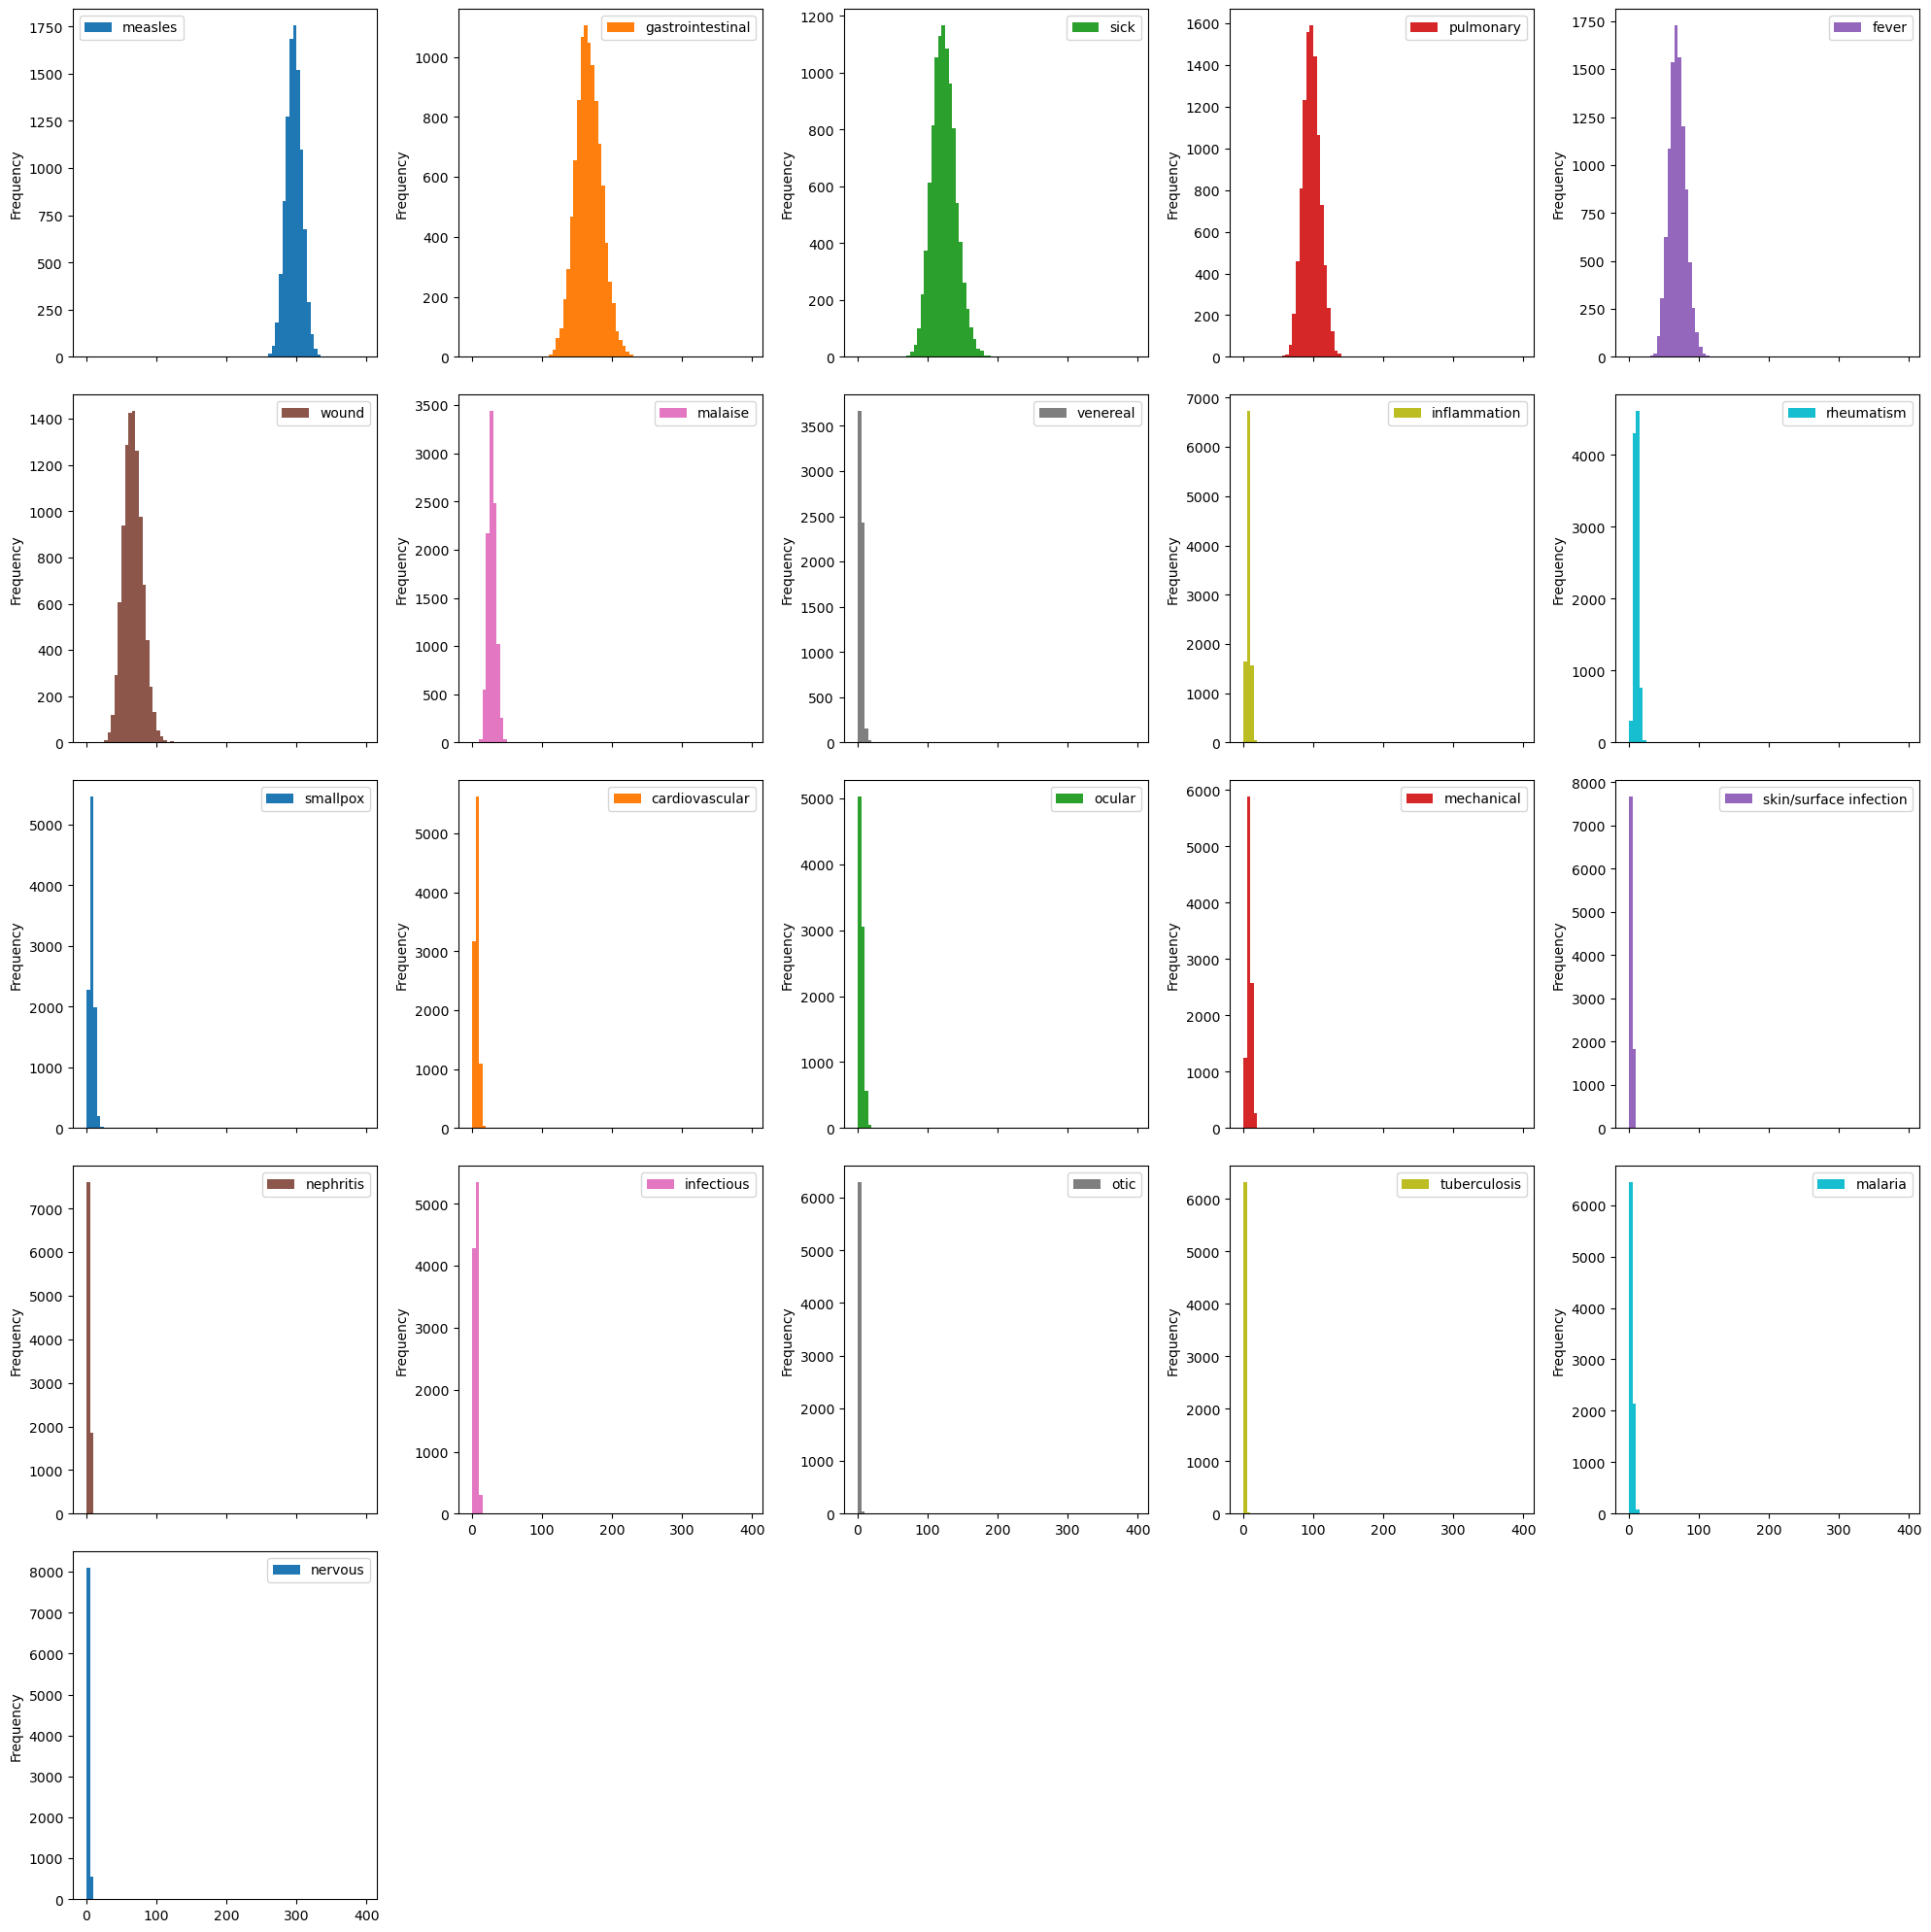

In [144]:
resultsBySample.plot(kind='hist', subplots=True, figsize=(20, 20), layout=(5,5), bins=range(0, 400, 5))
#plt.title('Histograms of All Condition Categories')
plt.tight_layout()
#plt.show()
plt.savefig('~/projects/measles_analysis/ResultsBySampleHistograms.png')